# When Attribution Models Disagree: How Different Methods Lead to Different Strategies

## A practical study of customer journeys showing how attribution methods influence budget allocation.

---

## Business Question

> Which channels should get credit for conversions?

## Dataset

This notebook uses the Kaggle **Multi-Touch Attribution** dataset.
>https://www.kaggle.com/datasets/vivekparasharr/multi-touch-attribution

The dataset contains user-level marketing interactions with timestamp, channel, campaign, conversion, revenue, and other fields.

## Core Message

Multi-touch attribution is useful for understanding observed customer journeys, but different attribution methods answer different questions.

This notebook compares:

1. First-touch attribution
2. Last-touch attribution
3. Linear attribution
4. Simple model-based attribution

The goal is to show that attribution is assumption-driven.

## 1. Setup and Data Loading

The raw data is touchpoint-level. Each row is one user interaction with a marketing channel.

To perform attribution, I first convert the raw data into **customer journeys**: ordered sequences of touchpoints for each user.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = "data/multi_touch_attribution_data.csv"
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'multi_touch_attribution_data.csv'. "
        "Place the CSV in the same folder as this notebook or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 5)


,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


## 2. Data Setup

The required fields are:

- User ID
- Timestamp
- Channel
- Campaign
- Conversion

The timestamp is critical because first-touch and last-touch attribution depend entirely on event order.

In [2]:
user_col = "User ID"
time_col = "Timestamp"
channel_col = "Channel"
campaign_col = "Campaign"
conversion_col = "Conversion"

required_cols = [user_col, time_col, channel_col, campaign_col, conversion_col]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df[time_col] = pd.to_datetime(df[time_col])
df["converted_touch"] = df[conversion_col].astype(str).str.lower().eq("yes").astype(int)
df = df.sort_values([user_col, time_col]).reset_index(drop=True)

print("Rows:", len(df))
print("Unique users:", df[user_col].nunique())
print("Date range:", df[time_col].min(), "to", df[time_col].max())

print("\nChannel distribution:")
display(df[channel_col].value_counts().to_frame("touchpoints"))

print("\nTouchpoint-level conversion flag:")
display(df[conversion_col].value_counts().to_frame("count"))

Rows: 10000
Unique users: 2847
Date range: 2025-02-10 00:00:22 to 2025-02-11 23:59:58

Channel distribution:


,touchpoints
Channel,
Direct Traffic,1721
Referral,1685
Display Ads,1669
Social Media,1662
Email,1654
Search Ads,1609



Touchpoint-level conversion flag:


,count
Conversion,
No,5056
Yes,4944


## 3. Build Customer Journeys

I aggregate touchpoints into one row per user.

For each user, I keep:

- ordered channel path,
- ordered campaign path,
- whether the user converted at least once,
- number of touches,
- first and last interaction time.

This creates the base table for attribution.

In [3]:
journeys = (
    df.groupby(user_col)
      .agg(
          path=(channel_col, list),
          campaigns=(campaign_col, list),
          converted=("converted_touch", "max"),
          first_time=(time_col, "min"),
          last_time=(time_col, "max"),
          n_touches=(channel_col, "size"),
      )
      .reset_index()
)

journeys["path_str"] = journeys["path"].apply(lambda x: " > ".join(x))

print("Journeys:", len(journeys))
print("Journey-level conversion rate:", journeys["converted"].mean())
display(journeys[["path_str", "converted", "n_touches"]].head(10))
display(journeys["n_touches"].describe().to_frame("n_touches"))

Journeys: 2847
Journey-level conversion rate: 0.8363189322093432


,path_str,converted,n_touches
0,Search Ads > Display Ads,1,2
1,Search Ads > Display Ads,1,2
2,Social Media > Direct Traffic > Email,1,3
3,Search Ads > Social Media > Social Media > Sea...,1,5
4,Display Ads > Email > Referral > Display Ads >...,1,6
5,Referral > Email > Referral > Direct Traffic >...,1,5
6,Social Media > Display Ads > Display Ads,1,3
7,Email > Referral,1,2
8,Display Ads > Direct Traffic > Display Ads > S...,1,5
9,Social Media > Referral > Direct Traffic > Soc...,1,4


,n_touches
count,"2,847.0000"
mean,3.5125
std,1.7707
min,1.0000
25%,2.0000
50%,3.0000
75%,5.0000
max,12.0000


### Journey Interpretation

If most users had only one touchpoint, MTA would not be very interesting because first-touch and last-touch would mostly match.

The more multi-touch journeys exist, the more attribution becomes a real credit-assignment problem.

## 4. Most Common Customer Paths

Before assigning credit, I inspect common journeys.

This gives the analysis a practical foundation. Attribution results should be interpreted in the context of actual observed paths.

,path,number_of_users
0,Search Ads,65
1,Display Ads,60
2,Direct Traffic,58
3,Email,54
4,Social Media,54
5,Referral,52
6,Referral > Social Media,26
7,Display Ads > Direct Traffic,24
8,Referral > Search Ads,23
9,Referral > Email,21


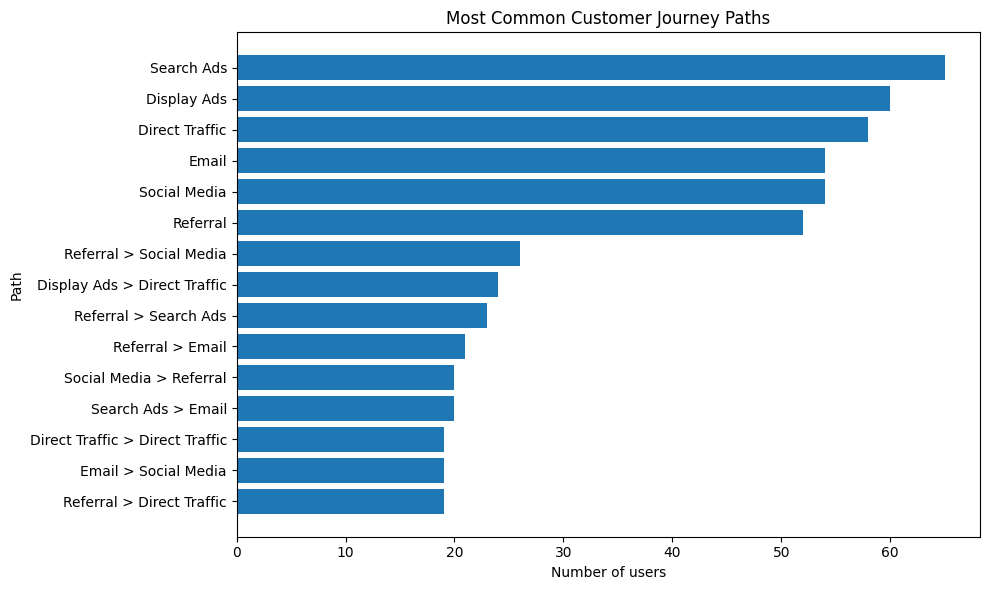

In [4]:
top_paths = journeys["path_str"].value_counts().head(15).reset_index()
top_paths.columns = ["path", "number_of_users"]

display(top_paths)

plt.figure(figsize=(10, 6))
plt.barh(top_paths["path"][::-1], top_paths["number_of_users"][::-1])
plt.title("Most Common Customer Journey Paths")
plt.xlabel("Number of users")
plt.ylabel("Path")
plt.tight_layout()
plt.show()

## 5. First-Touch Attribution

First-touch gives 100% of conversion credit to the first channel in a converting user’s path.

Business interpretation:

> This method rewards channels that start journeys.

It is useful when the business cares about demand creation, but it can under-credit channels that help close conversions later.

In [5]:
converted_journeys = journeys[journeys["converted"] == 1].copy()
channels = sorted(df[channel_col].unique())

first_counter = Counter()

for path in converted_journeys["path"]:
    first_counter[path[0]] += 1

first_touch = pd.DataFrame({
    "channel": channels,
    "first_touch_credit": [first_counter[c] for c in channels],
})

first_touch["first_touch_share"] = first_touch["first_touch_credit"] / first_touch["first_touch_credit"].sum()

display(first_touch.sort_values("first_touch_share", ascending=False))

,channel,first_touch_credit,first_touch_share
1,Display Ads,428,0.1798
0,Direct Traffic,411,0.1726
3,Referral,408,0.1714
5,Social Media,389,0.1634
2,Email,374,0.1571
4,Search Ads,371,0.1558


## 6. Last-Touch Attribution

Last-touch gives 100% of conversion credit to the final channel in a converting user’s path.

Business interpretation:

> This method rewards channels closest to conversion.

It is easy to explain, but it can over-credit bottom-of-funnel channels.

In [6]:
last_counter = Counter()

for path in converted_journeys["path"]:
    last_counter[path[-1]] += 1

last_touch = pd.DataFrame({
    "channel": channels,
    "last_touch_credit": [last_counter[c] for c in channels],
})

last_touch["last_touch_share"] = last_touch["last_touch_credit"] / last_touch["last_touch_credit"].sum()

display(last_touch.sort_values("last_touch_share", ascending=False))

,channel,last_touch_credit,last_touch_share
0,Direct Traffic,425,0.1785
1,Display Ads,401,0.1684
4,Search Ads,395,0.1659
2,Email,393,0.1651
3,Referral,384,0.1613
5,Social Media,383,0.1609


## 7. Linear Attribution

Linear attribution divides credit equally across all channels in the path.

Business interpretation:

> This method assumes every touchpoint contributed equally.

It is simple and balanced, but it ignores position, timing, and true influence.

In [7]:
linear_counter = Counter()

for path in converted_journeys["path"]:
    credit = 1 / len(path)
    for ch in path:
        linear_counter[ch] += credit

linear = pd.DataFrame({
    "channel": channels,
    "linear_credit": [linear_counter[c] for c in channels],
})

linear["linear_share"] = linear["linear_credit"] / linear["linear_credit"].sum()

display(linear.sort_values("linear_share", ascending=False))

,channel,linear_credit,linear_share
0,Direct Traffic,408.2766,0.1715
1,Display Ads,407.1562,0.1710
3,Referral,398.7049,0.1675
5,Social Media,397.6037,0.1670
2,Email,387.7168,0.1628
4,Search Ads,381.5418,0.1602


## 8. Compare Rule-Based Attribution Methods

This is the main tension of the post.

The same customer journeys can produce different answers depending on the attribution rule.

,channel,first_touch_share,last_touch_share,linear_share
0,Direct Traffic,0.1726,0.1785,0.1715
1,Display Ads,0.1798,0.1684,0.1710
3,Referral,0.1714,0.1613,0.1675
5,Social Media,0.1634,0.1609,0.1670
2,Email,0.1571,0.1651,0.1628
4,Search Ads,0.1558,0.1659,0.1602


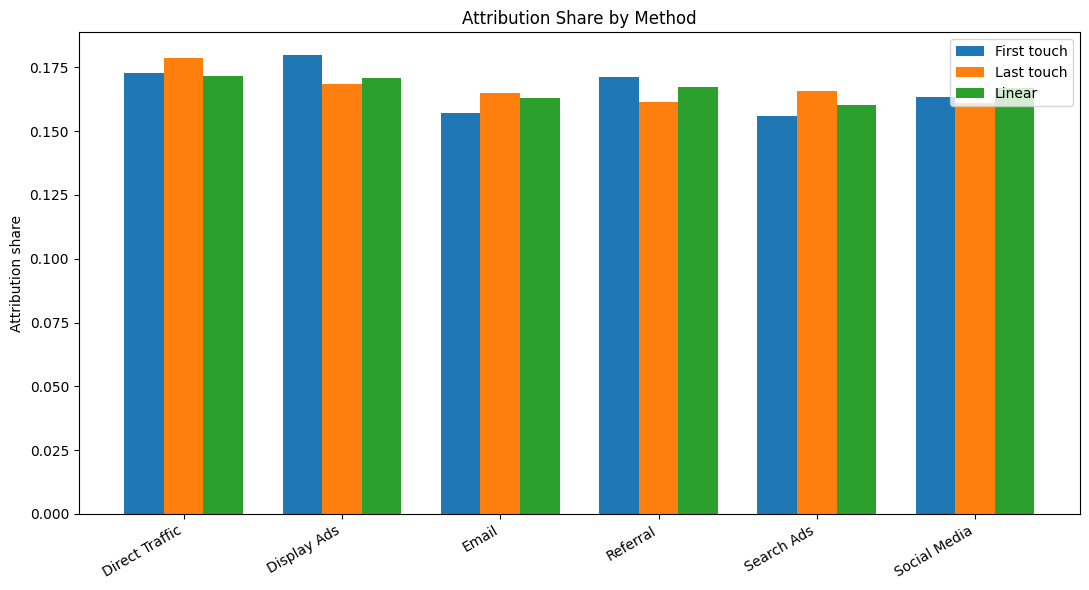

In [8]:
attrib = (
    first_touch[["channel", "first_touch_share"]]
    .merge(last_touch[["channel", "last_touch_share"]], on="channel")
    .merge(linear[["channel", "linear_share"]], on="channel")
)

display(attrib.sort_values("linear_share", ascending=False))

plot_df = attrib.set_index("channel")[["first_touch_share", "last_touch_share", "linear_share"]]

plt.figure(figsize=(11, 6))
x = np.arange(len(plot_df.index))
w = 0.25

plt.bar(x - w, plot_df["first_touch_share"], w, label="First touch")
plt.bar(x, plot_df["last_touch_share"], w, label="Last touch")
plt.bar(x + w, plot_df["linear_share"], w, label="Linear")

plt.xticks(x, plot_df.index, rotation=30, ha="right")
plt.ylabel("Attribution share")
plt.title("Attribution Share by Method")
plt.legend()
plt.tight_layout()
plt.show()

## Three Models, Three Different Answers

Applying:

- First-touch attribution
- Last-touch attribution
- Linear attribution

can produce different channel rankings.

> Same data → different conclusions.

Each rule values a different part of the funnel:

- First-touch favors introducers.
- Last-touch favors closers.
- Linear favors broad participation.

This is why attribution is not a single objective truth. It is a structured credit allocation rule.

## Three Models, Three Different Budget Decisions

If I were to act on each model:

- First-touch would push me to invest more in awareness or acquisition-starting channels.
- Last-touch would push me to invest more in closing channels.
- Linear attribution would suggest a more balanced allocation.

These are not small differences. They can lead to fundamentally different marketing strategies.

> Attribution choice = strategy choice.

## Attribution Is a Choice, Not a Discovery

Attribution does not discover the true contribution of each channel.

It encodes assumptions:

- First-touch assumes the first interaction is most important.
- Last-touch assumes the final interaction is most important.
- Linear assumes all interactions are equally important.

> Attribution is assumption-driven.

That does not make it useless. It means the method should match the business question.

## 9. Raw Conversion Difference by Channel Presence

Now I ask a simple diagnostic question:

> Do users who saw a channel convert more often than users who did not?

This is not causal. It is still useful because it shows which channels are associated with conversion at the journey level.

,channel,reach_share,conversion_rate_if_seen,conversion_rate_if_not_seen,raw_conversion_lift
1,Display Ads,0.4405,0.9075,0.7803,0.1272
3,Referral,0.4535,0.8900,0.7918,0.0982
5,Social Media,0.4514,0.8864,0.7951,0.0912
0,Direct Traffic,0.4521,0.8858,0.7955,0.0903
2,Email,0.4440,0.8861,0.7966,0.0895
4,Search Ads,0.4422,0.8761,0.8048,0.0713


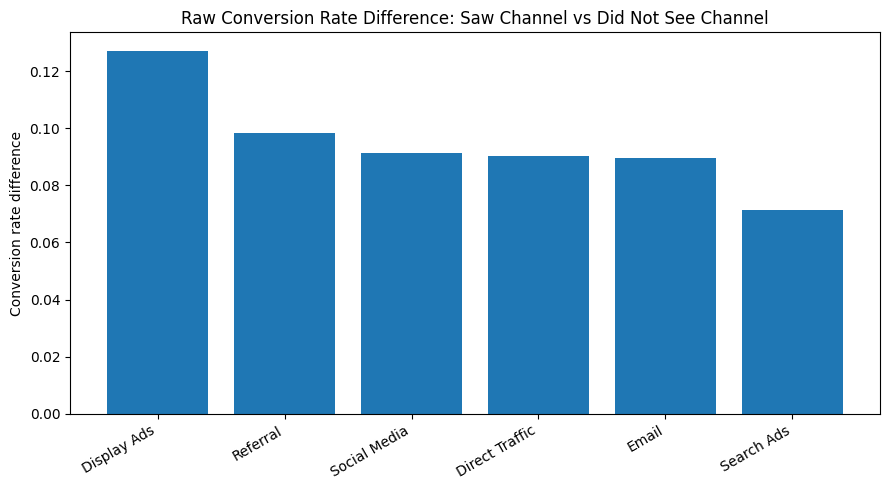

In [9]:
channel_counts = pd.DataFrame([
    {ch: path.count(ch) for ch in channels}
    for path in journeys["path"]
]).fillna(0)

channel_presence = (channel_counts > 0).astype(int)
y = journeys["converted"].values

rows = []

for ch in channels:
    saw = channel_presence[ch].astype(bool).values

    conv_seen = y[saw].mean() if saw.any() else np.nan
    conv_not = y[~saw].mean() if (~saw).any() else np.nan

    rows.append({
        "channel": ch,
        "reach_share": saw.mean(),
        "conversion_rate_if_seen": conv_seen,
        "conversion_rate_if_not_seen": conv_not,
        "raw_conversion_lift": conv_seen - conv_not,
    })

presence = pd.DataFrame(rows).sort_values("raw_conversion_lift", ascending=False)

display(presence)

plt.figure(figsize=(9, 5))
plt.bar(presence["channel"], presence["raw_conversion_lift"])
plt.title("Raw Conversion Rate Difference: Saw Channel vs Did Not See Channel")
plt.ylabel("Conversion rate difference")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

A higher conversion rate among users who saw a channel does not prove that the channel caused conversion.

Users who saw that channel may have:

- higher intent,
- more total touchpoints,
- different campaigns,
- different funnel stage.

This is where attribution and incrementality diverge.

## 10. Model-Based Attribution

Rule-based attribution uses fixed rules. Model-based attribution uses journey features to predict conversion.

Here I build a simple logistic regression model using:

- channel count features,
- channel presence features,
- total number of touches.

This is still not causal, but it gives a richer predictive view than fixed credit rules.

In [10]:
X_counts = channel_counts.add_prefix("count_")
X_presence = channel_presence.add_prefix("saw_")

X = pd.concat([X_counts, X_presence], axis=1)
X["n_touches"] = journeys["n_touches"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])

logit.fit(X_train, y_train)
pred = logit.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)

print(f"Test AUC: {auc:,.3f}")

coefs = pd.Series(logit.named_steps["model"].coef_[0], index=X.columns)

display(
    coefs.sort_values(key=np.abs, ascending=False)
         .head(20)
         .to_frame("coefficient")
)

Test AUC: 0.754


,coefficient
n_touches,0.6005
count_Referral,0.4721
saw_Display Ads,0.4604
count_Direct Traffic,0.3821
saw_Email,0.3272
count_Social Media,0.2308
saw_Social Media,0.1750
count_Search Ads,0.1663
count_Email,0.0888
saw_Search Ads,0.0867


### Model-Based Interpretation

The model-based view asks:

> Which journey features help predict conversion?

This can be more flexible than first-touch or last-touch, but it still estimates association.

If `n_touches` is highly predictive, that tells us something important: users with more interactions are more likely to convert. That can make channels appearing in longer journeys look more valuable.

## Why Longer Journeys Bias Attribution

Users with more touches often convert at higher rates.

So:

- channels in long journeys receive more credit,
- even if they are not the true drivers.

> Attribution rewards presence in converting journeys, not necessarily causal impact.

This is one of the most important limitations to understand before using attribution for budget allocation.

## 11. Model-Based Channel Signals

To compare with rule-based attribution, I extract channel presence and count coefficients.

,channel,presence_coefficient,count_coefficient,abs_presence_coefficient
1,Display Ads,0.4604,0.0536,0.4604
2,Email,0.3272,0.0888,0.3272
5,Social Media,0.1750,0.2308,0.1750
4,Search Ads,0.0867,0.1663,0.0867
3,Referral,-0.0436,0.4721,0.0436
0,Direct Traffic,0.0381,0.3821,0.0381


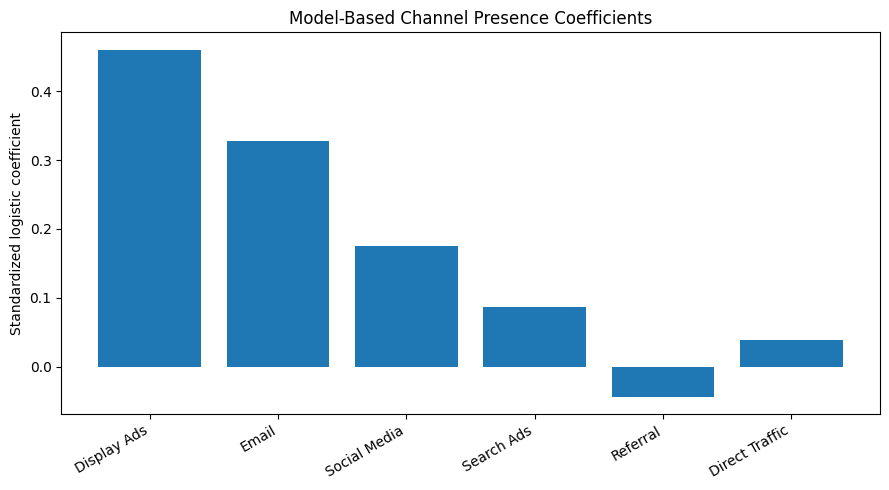

In [11]:
model_based = pd.DataFrame({
    "channel": channels,
    "presence_coefficient": [coefs.get(f"saw_{ch}", 0) for ch in channels],
    "count_coefficient": [coefs.get(f"count_{ch}", 0) for ch in channels],
})

model_based["abs_presence_coefficient"] = model_based["presence_coefficient"].abs()
model_based = model_based.sort_values("abs_presence_coefficient", ascending=False)

display(model_based)

plt.figure(figsize=(9, 5))
plt.bar(model_based["channel"], model_based["presence_coefficient"])
plt.title("Model-Based Channel Presence Coefficients")
plt.ylabel("Standardized logistic coefficient")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Model-Based Channel Interpretation

A positive model coefficient means the channel feature is associated with higher conversion probability after accounting for other model features.

It does not mean the channel caused the conversion.

The value of this section is comparison: if the model-based ranking differs from first-touch or last-touch, it shows that different attribution frameworks produce different business narratives.

## 12. Final Comparison Table

This table puts all attribution views together.

The most important columns are not just the shares themselves, but the rankings implied by each method.

In [12]:
final = (
    attrib
    .merge(presence[["channel", "raw_conversion_lift"]], on="channel", how="left")
    .merge(model_based[["channel", "presence_coefficient", "count_coefficient"]], on="channel", how="left")
)

for col in [
    "first_touch_share",
    "last_touch_share",
    "linear_share",
    "raw_conversion_lift",
    "presence_coefficient",
]:
    final[f"rank_{col}"] = final[col].rank(ascending=False, method="first").astype(int)

display(final.sort_values("linear_share", ascending=False))

,channel,first_touch_share,last_touch_share,linear_share,raw_conversion_lift,presence_coefficient,count_coefficient,rank_first_touch_share,rank_last_touch_share,rank_linear_share,rank_raw_conversion_lift,rank_presence_coefficient
0,Direct Traffic,0.1726,0.1785,0.1715,0.0903,0.0381,0.3821,2,1,1,4,5
1,Display Ads,0.1798,0.1684,0.1710,0.1272,0.4604,0.0536,1,2,2,1,1
3,Referral,0.1714,0.1613,0.1675,0.0982,-0.0436,0.4721,3,5,3,2,6
5,Social Media,0.1634,0.1609,0.1670,0.0912,0.1750,0.2308,4,6,4,3,3
2,Email,0.1571,0.1651,0.1628,0.0895,0.3272,0.0888,5,4,5,5,2
4,Search Ads,0.1558,0.1659,0.1602,0.0713,0.0867,0.1663,6,3,6,6,4


## 13. What This Means for Decision-Making

If I use first-touch, I may invest more in channels that start journeys.

If I use last-touch, I may invest more in channels near conversion.

If I use linear attribution, I spread credit across the funnel.

If I use model-based attribution, I emphasize channels that help predict conversion.

These are different decision frameworks. A practitioner should choose the attribution method based on the business question, not because one method is universally correct.

## 14. Where Attribution Can Mislead

Attribution can mislead when it is interpreted as causal impact.

Common issues:

1. **High-intent users may receive more touches.**  
   Channels in those paths get more credit, even if users were already likely to convert.

2. **Bottom-of-funnel channels may be over-credited.**  
   Last-touch can reward the final interaction even when earlier channels created demand.

3. **Rule-based methods encode assumptions.**  
   First-touch, last-touch, and linear attribution are not discovered truths.

4. **Predictive models still estimate association.**  
   Model-based attribution can be richer, but it still does not answer what would have happened without the channel.

## Final Takeaway

> Attribution explains association, not causation.

It is useful for:

- understanding customer journeys,
- comparing credit-allocation assumptions,
- generating hypotheses,
- guiding further testing.

It is not sufficient for final budget decisions in isolation.

The strongest use of MTA is diagnostic: understand the journey first, then validate major investment decisions with incrementality evidence.